# PadChest-GR — fetch and prepare

Official BSC release → 4,555 chest X-rays as 518 px PNGs + a manifest joining
each image to its sentences and bounding boxes.


### Resuming a later session

    !tar -xf {OUT_ROOT}/pcgr_png.tar -C /content
    pc_all = json.load(open('/content/pc_png/manifest.json'))



## 0. Setup and disk helpers

In [ ]:
import os, re, json, time, glob, shutil, random, subprocess
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def free_gb(path="/content"):
    s = os.statvfs(path)
    return s.f_bavail * s.f_frsize / 1e9

def used_report():
    print(f"free: {free_gb():.1f} GB")
    for d_ in sorted(os.listdir("/content")):
        p = f"/content/{d_}"
        if d_ == "drive" or not os.path.isdir(p):
            continue
        sz = subprocess.run(["du", "-sh", p], capture_output=True,
                            text=True).stdout.split()
        if sz: print(f"  {sz[0]:>8s}  {d_}")

used_report()

free: 70.4 GB
      144K  .config
       55M  sample_data


## 1. Mount Drive and clear stale state



In [ ]:
from google.colab import drive

for d_ in ["_batch", "half", "pcgr_raw", "tmp_raw", "_probe"]:
    p = f"/content/{d_}"
    if os.path.exists(p):
        print("removing", p); shutil.rmtree(p, ignore_errors=True)
for f_ in ["/content/PadChest_GR_full.zip", "/content/_list.txt"]:
    if os.path.exists(f_): os.remove(f_)

try:
    drive.flush_and_unmount()
except Exception:
    pass
for p in ["/root/.cache/drive_fs", "/tmp/drive_fs",
          "/root/.config/Google/DriveFS"]:
    subprocess.run(["rm", "-rf", p], capture_output=True)

drive.mount("/content/drive")
OUT_ROOT = "/content/drive/MyDrive/MSC_VLM_GROUNDED"
os.makedirs(OUT_ROOT, exist_ok=True)

DAV = "https://b2drop.bsc.es/nextcloud/public.php/dav/files/PadChest-GR"
RAW = "/content/pcgr_zip"
PNG_LOCAL = "/content/pc_png"
REPORTS = "/content/grounded_reports.json"
PNG_TAR = f"{OUT_ROOT}/pcgr_png.tar"
os.makedirs(RAW, exist_ok=True); os.makedirs(PNG_LOCAL, exist_ok=True)

print(f"\nfree: {free_gb():.1f} GB")

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive

free: 70.4 GB


## 2. Annotations



In [ ]:
if not (os.path.exists(REPORTS) and os.path.getsize(REPORTS) > 1e6):
    os.system(f'wget -q -c -O "{REPORTS}" "{DAV}/grounded_reports_20240819.json"')

d = json.load(open(REPORTS))
nf = sum(len(r["findings"]) for r in d)
nb = sum(1 for r in d for f in r["findings"] if f.get("boxes"))
print(f"{len(d)} studies      (expect 4555)")
print(f"{nf} findings     (expect 10479)")
print(f"{nb} boxed ({100*nb/nf:.1f}%)  (expect 6217, 59.3%)")
assert len(d) == 4555, "annotation file incomplete — delete and re-run"

shutil.copy(REPORTS, f"{OUT_ROOT}/grounded_reports_20240819.json")
print("\nbacked up to Drive")

4555 studies      (expect 4555)
10479 findings     (expect 10479)
6217 boxed (59.3%)  (expect 6217, 59.3%)

backed up to Drive


## 3. Download the split archive (37 parts, ~36 GB)



In [ ]:
listing = subprocess.run(["curl", "-s", "-X", "PROPFIND", "-H", "Depth: 1",
                          f"{DAV}/Padchest_GR_files/"],
                         capture_output=True, text=True).stdout
parts = sorted(set(re.findall(r"<d:href>[^<]*/(PadChest_GR\.zip[^<]*)</d:href>",
                              listing)))
print(f"{len(parts)} parts on the server")
assert parts, "PROPFIND returned nothing — check the DAV URL"

PART_GB, FLOOR_GB = 1.1, 20
t0 = time.time()
for i, part in enumerate(parts):
    dst = f"{RAW}/{part}"
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        continue
    if free_gb() < PART_GB + FLOOR_GB:
        print(f"STOP: {free_gb():.1f} GB free"); break
    print(f"  [{i+1}/{len(parts)}] {part} ...", end=" ", flush=True)
    os.system(f'wget -q -c -O "{dst}" "{DAV}/Padchest_GR_files/{part}"')
    print(f"{os.path.getsize(dst)/1e9:.2f} GB | free {free_gb():.0f} GB | "
          f"{(time.time()-t0)/60:.0f} min")

have = [p for p in parts if os.path.exists(f"{RAW}/{p}")
        and os.path.getsize(f"{RAW}/{p}") > 0]
tot = sum(os.path.getsize(f"{RAW}/{p}") for p in have)
print(f"\n{len(have)}/{len(parts)} parts | {tot/1e9:.1f} GB | "
      f"{free_gb():.1f} GB free")
assert len(have) == len(parts), "incomplete — re-run this cell, it resumes"

37 parts on the server
  [1/37] PadChest_GR.zip.001 ... 1.05 GB | free 69 GB | 0 min
  [2/37] PadChest_GR.zip.002 ... 1.05 GB | free 68 GB | 1 min
  [3/37] PadChest_GR.zip.003 ... 1.05 GB | free 67 GB | 1 min
  [4/37] PadChest_GR.zip.004 ... 1.05 GB | free 66 GB | 1 min
  [5/37] PadChest_GR.zip.005 ... 1.05 GB | free 65 GB | 2 min
  [6/37] PadChest_GR.zip.006 ... 1.05 GB | free 64 GB | 2 min
  [7/37] PadChest_GR.zip.007 ... 1.05 GB | free 63 GB | 4 min
  [8/37] PadChest_GR.zip.008 ... 1.05 GB | free 62 GB | 4 min
  [9/37] PadChest_GR.zip.009 ... 1.05 GB | free 61 GB | 5 min
  [10/37] PadChest_GR.zip.010 ... 1.05 GB | free 60 GB | 5 min
  [11/37] PadChest_GR.zip.011 ... 1.05 GB | free 59 GB | 5 min
  [12/37] PadChest_GR.zip.012 ... 1.05 GB | free 58 GB | 6 min
  [13/37] PadChest_GR.zip.013 ... 1.05 GB | free 57 GB | 6 min
  [14/37] PadChest_GR.zip.014 ... 1.05 GB | free 56 GB | 6 min
  [15/37] PadChest_GR.zip.015 ... 1.05 GB | free 55 GB | 7 min
  [16/37] PadChest_GR.zip.016 ... 1.05 GB

## 4. Verify the archive



In [ ]:
subprocess.run(["apt-get", "install", "-y", "-q", "p7zip-full"],
               capture_output=True)
r = subprocess.run(["7z", "t", f"{RAW}/PadChest_GR.zip.001"],
                   capture_output=True, text=True)
assert "Everything is Ok" in r.stdout, "ARCHIVE CORRUPT — re-download parts"
m = re.search(r"Files:\s+(\d+)", r.stdout)
print(f"CRC OK | files in archive: {m.group(1) if m else '?'} (expect 4555)")

lst = subprocess.run(["7z", "l", f"{RAW}/PadChest_GR.zip.001"],
                     capture_output=True, text=True).stdout
png0 = [l.split()[-1] for l in lst.split("\n") if l.strip().endswith(".png")][0]
PREFIX = png0.rsplit("/", 1)[0] + "/" if "/" in png0 else ""
print(f"internal prefix: {PREFIX!r}")
print(f"example: {png0}")

CRC OK | files in archive: 4555 (expect 4555)
internal prefix: 'PadChest_GR/'
example: PadChest_GR/100171984015994193562581691034118023629_370g35.png


## 5. Extract and convert in batches



In [ ]:
BATCH_SIZE, MIN_FREE_GB = 570, 15


def load_cxr(path, img_size=518):
    """
    16-bit ('I;16') -> 8-bit RGB.

    PIL's convert("RGB") CLIPS values above 255 to white. Real PadChest pixels
    run to ~65535 with a mean near 33000, so ~99.7% saturate and the result is
    near-binary. Rescaling over the actual [min, max] keeps the full range.

    Resizes so the SHORT side is img_size; aspect ratio is preserved, which is
    what keeps the normalised boxes valid.
    """
    a = np.array(Image.open(path)).astype(np.float32)
    if a.ndim == 3:
        a = a[..., 0]
    lo, hi = a.min(), a.max()
    a = (a - lo) / max(1e-6, hi - lo) * 255.0
    im8 = Image.fromarray(a.astype(np.uint8)).convert("RGB")
    W, H = im8.size
    sc = img_size / min(W, H)
    return im8.resize((int(W*sc), int(H*sc)), Image.LANCZOS)


names = [r["ImageID"] for r in d]
todo = [n for n in names if not os.path.exists(f"{PNG_LOCAL}/{n}")]
batches = [todo[i:i+BATCH_SIZE] for i in range(0, len(todo), BATCH_SIZE)]
print(f"{len(names)} images | {len(names)-len(todo)} done | {len(todo)} to do")
print(f"{len(batches)} batches of <= {BATCH_SIZE}\n")

t0 = time.time()
for bi, batch in enumerate(batches):
    if free_gb() < MIN_FREE_GB:
        print(f"STOP: {free_gb():.1f} GB free, below the floor"); break
    tmp = "/content/_batch"
    shutil.rmtree(tmp, ignore_errors=True); os.makedirs(tmp, exist_ok=True)
    with open("/content/_list.txt", "w") as fh:
        fh.write("\n".join(f"{PREFIX}{n}" for n in batch))
    subprocess.run(["7z", "x", f"{RAW}/PadChest_GR.zip.001", f"-o{tmp}",
                    "-y", "-i@/content/_list.txt"], capture_output=True)

    idx = {f: os.path.join(root, f) for root, _, fs in os.walk(tmp)
           for f in fs if f.endswith(".png")}
    ok = 0
    for fn in batch:
        src = idx.get(fn)
        if src is None: continue
        try:
            load_cxr(src).save(f"{PNG_LOCAL}/{fn}", optimize=True)
            ok += 1
        except Exception as e:
            print(f"    failed {fn}: {str(e)[:60]}")
    shutil.rmtree(tmp, ignore_errors=True)

    n_png = len([f for f in os.listdir(PNG_LOCAL) if f.endswith(".png")])
    print(f"  batch {bi+1}/{len(batches)}: extracted {len(idx)}, converted {ok} "
          f"| total {n_png} | {free_gb():.0f} GB free "
          f"| {(time.time()-t0)/60:.0f} min")

print(f"\nconverted {len([f for f in os.listdir(PNG_LOCAL) if f.endswith('.png')])}"
      f"/{len(names)}")
print("\nIf batch 1 reported 'converted 0', STOP — the file list did not match.")

4555 images | 0 done | 4555 to do
8 batches of <= 570

  batch 1/8: extracted 570, converted 570 | total 570 | 32 GB free | 9 min
  batch 2/8: extracted 570, converted 570 | total 1140 | 32 GB free | 17 min
  batch 3/8: extracted 570, converted 570 | total 1710 | 32 GB free | 26 min
  batch 4/8: extracted 570, converted 570 | total 2280 | 31 GB free | 34 min
  batch 5/8: extracted 570, converted 570 | total 2850 | 31 GB free | 42 min
  batch 6/8: extracted 570, converted 570 | total 3420 | 31 GB free | 51 min
  batch 7/8: extracted 570, converted 570 | total 3990 | 31 GB free | 60 min
  batch 8/8: extracted 565, converted 565 | total 4555 | 31 GB free | 68 min

converted 4555/4555

If batch 1 reported 'converted 0', STOP — the file list did not match.


## 6. Verify the images, then archive immediately



4555 PNGs (expect 4555)


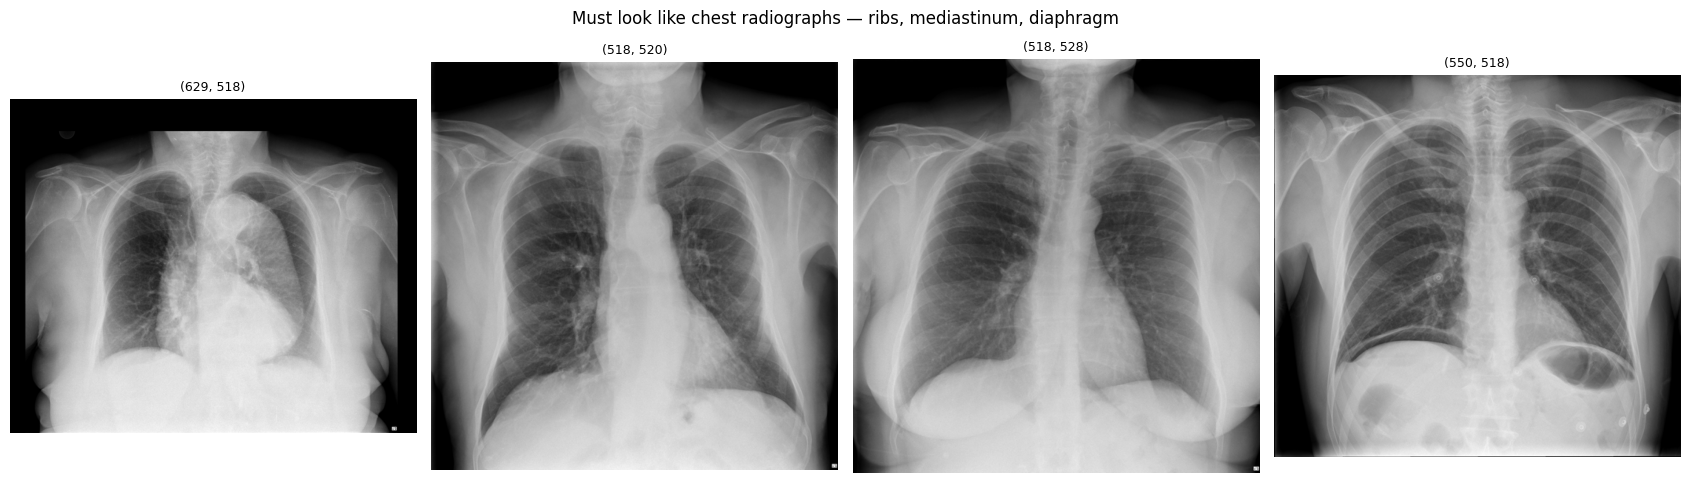

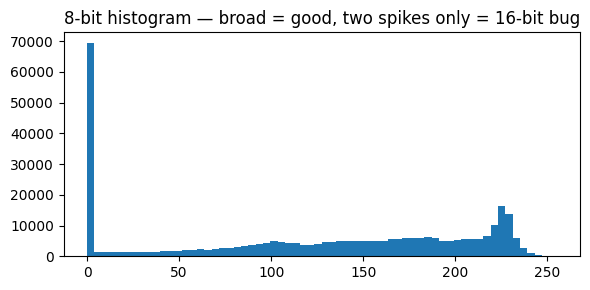

intensity spread: min 0 max 255 mean 122


In [ ]:
files = sorted(f for f in os.listdir(PNG_LOCAL) if f.endswith(".png"))
print(f"{len(files)} PNGs (expect 4555)")
assert len(files) == 4555, "incomplete — re-run section 5, it resumes"

# 1. are they readable radiographs, not the 16-bit truncation artefact?
fig, ax = plt.subplots(1, 4, figsize=(17, 5))
for a_, f_ in zip(ax, files[:4]):
    im = Image.open(f"{PNG_LOCAL}/{f_}")
    a_.imshow(im); a_.axis("off"); a_.set_title(f"{im.size}", fontsize=9)
plt.suptitle("Must look like chest radiographs — ribs, mediastinum, diaphragm")
plt.tight_layout(); plt.show()

# 2. histogram: a broad bimodal spread, not two spikes at 0 and 255
g = np.array(Image.open(f"{PNG_LOCAL}/{files[0]}").convert("L")).ravel()
plt.figure(figsize=(6, 3)); plt.hist(g, bins=64)
plt.title("8-bit histogram — broad = good, two spikes only = 16-bit bug")
plt.tight_layout(); plt.show()
print(f"intensity spread: min {g.min()} max {g.max()} mean {g.mean():.0f}")

In [ ]:
import os
import json

dd = json.load(open("/content/grounded_reports.json"))

json_ids = {r["ImageID"] for r in dd}
png_ids = {
    f for f in os.listdir("/content/pc_png")
    if f.lower().endswith(".png")
}

print("JSON unique ImageIDs:", len(json_ids))
print("PNG files:", len(png_ids))

missing = json_ids - png_ids
extra = png_ids - json_ids

print("Missing from PNG:", len(missing))
print("Extra PNGs:", len(extra))

if missing:
    print("\nExample missing:")
    print(next(iter(missing)))

if extra:
    print("\nExample extra:")
    print(next(iter(extra)))

In [ ]:
# ARCHIVE NOW — before the manifest, before anything else
subprocess.run(["tar", "-cf", PNG_TAR, "-C", "/content", "pc_png"])
print(f"archived {os.path.getsize(PNG_TAR)/1e6:.0f} MB -> {PNG_TAR}")
print("\nRestore in a later session with:")
print(f"  !tar -xf {PNG_TAR} -C /content")

archived 808 MB -> /content/drive/MyDrive/MSC_VLM_GROUNDED/pcgr_png.tar

Restore in a later session with:
  !tar -xf /content/drive/MyDrive/MSC_VLM_GROUNDED/pcgr_png.tar -C /content


## 7. Build the manifest

Joins each PNG to its sentences and boxes. Uses `boxes` only — `extra_boxes` is
a secondary annotation set.

In [ ]:
def build_manifest(reports_json, png_dir):
    dd = json.load(open(reports_json))
    manifest, skipped = [], 0
    for n, r in enumerate(dd):
        src = os.path.join(png_dir, r["ImageID"])
        if not os.path.exists(src):
            skipped += 1; continue
        W, H = Image.open(src).size

        sents, boxes = [], []
        for f in r["findings"]:
            s = (f.get("sentence_en") or "").strip()
            if not s: continue
            sents.append(s)
            boxes.append([[b[0]*W, b[1]*H, b[2]*W, b[3]*H]
                          for b in (f.get("boxes") or [])])
        if not sents: continue

        manifest.append({
            "path": src, "study_id": r["StudyID"], "image_id": r["ImageID"],
            "patient_id": r["StudyID"],
            "sentences": sents, "boxes": boxes,
            "abnormal": any(f.get("abnormal") for f in r["findings"]),
            "prior_image_id": r.get("PreviousImageID")})
        if n % 1000 == 0: print(f"  {n}/{len(dd)}")

    json.dump(manifest, open(f"{png_dir}/manifest.json", "w"))
    ns = sum(len(m["sentences"]) for m in manifest)
    ng = sum(sum(1 for b in m["boxes"] if b) for m in manifest)
    na = sum(1 for m in manifest if m["abnormal"])
    print(f"\n{len(manifest)} studies ({skipped} missing) | {na} abnormal "
          f"({100*na/max(1,len(manifest)):.1f}%)")
    print(f"{ns} sentences | {ng} boxed ({100*ng/max(1,ns):.1f}%) | "
          f"{ns-ng} abstentions ({100*(ns-ng)/max(1,ns):.1f}%)")
    print("\nEXPECT: 4555 studies | 10479 sentences | 6217 boxed (59.3%)")
    return manifest


pc_all = build_manifest(REPORTS, PNG_LOCAL)
assert len(pc_all) == 4555, "manifest incomplete"
subprocess.run(["cp", f"{PNG_LOCAL}/manifest.json", f"{OUT_ROOT}/manifest.json"])
print("manifest backed up to Drive")

  0/4555
  1000/4555
  2000/4555
  3000/4555
  4000/4555

4555 studies (0 missing) | 3099 abnormal (68.0%)
10479 sentences | 6217 boxed (59.3%) | 4262 abstentions (40.7%)

EXPECT: 4555 studies | 10479 sentences | 6217 boxed (59.3%)
manifest backed up to Drive


## 8. VERIFICATION GATE



6 multi-box studies shown



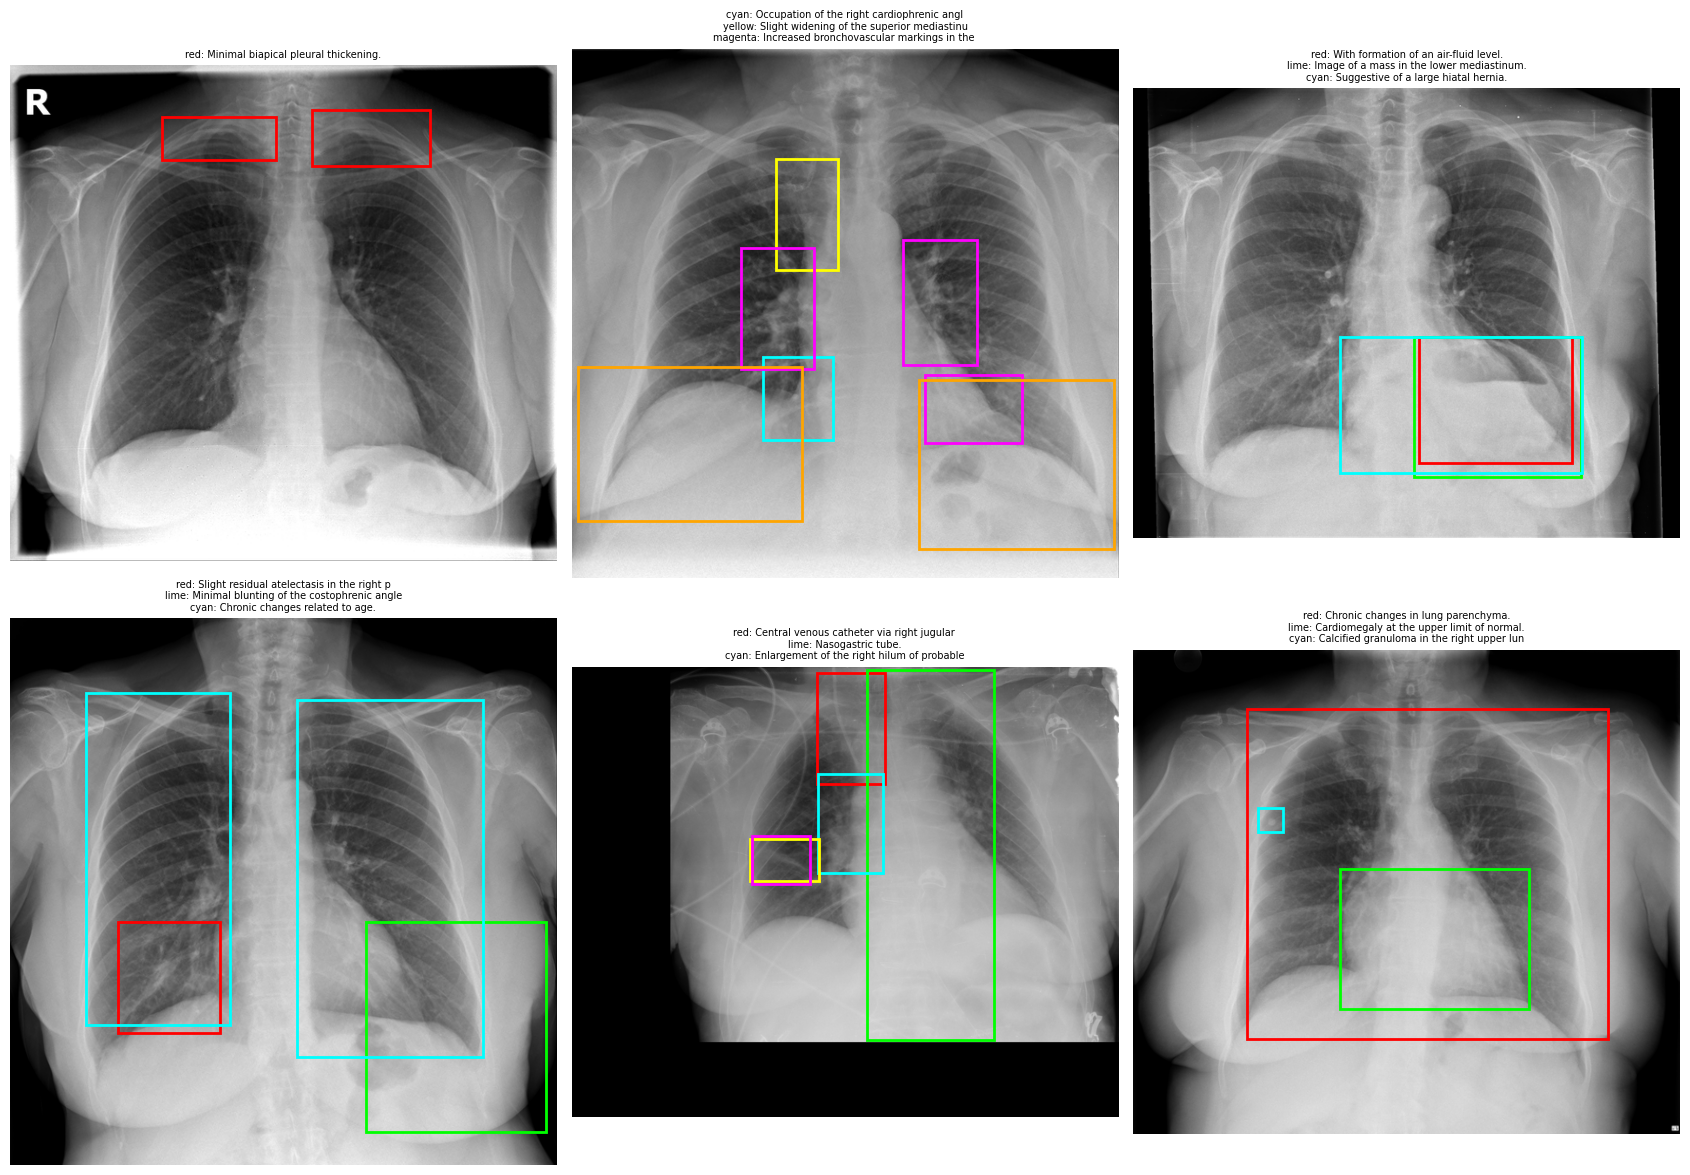

>>> Does each coloured box match its sentence anatomically?


In [ ]:
COLS = ["red", "lime", "cyan", "yellow", "magenta", "orange"]
multi = [m for m in pc_all if sum(len(b) for b in m["boxes"]) >= 2][:6]
print(f"{len(multi)} multi-box studies shown\n")

fig, ax = plt.subplots(2, 3, figsize=(17, 12)); ax = ax.flatten()
for k, st in enumerate(multi):
    ax[k].imshow(Image.open(st["path"]))
    lbls = []
    for si, bl in enumerate(st["boxes"]):
        c = COLS[si % len(COLS)]
        for b in bl:
            ax[k].add_patch(mpatches.Rectangle((b[0], b[1]), b[2]-b[0],
                                               b[3]-b[1], fill=False,
                                               ec=c, lw=2))
        if bl: lbls.append(f"{c}: {st['sentences'][si][:42]}")
    ax[k].set_title("\n".join(lbls[:3]), fontsize=7); ax[k].axis("off")
for k in range(len(multi), 6): ax[k].axis("off")
plt.tight_layout(); plt.show()
print(">>> Does each coloured box match its sentence anatomically?")

### 8.1 Reclaim the 36 GB

Only after the gate passes.

In [ ]:
# shutil.rmtree(RAW, ignore_errors=True)
# print(f"free: {free_gb():.1f} GB")
# used_report()

## 9. Patient-level stratified split

Grouped by patient so no patient's studies straddle splits, **and** stratified
on abnormality so the ~68/32 ratio holds in each split.

In [ ]:
def patient_level_split(manifest, frac=(0.80, 0.10, 0.10), seed=42):
    groups = {}
    for m in manifest:
        groups.setdefault(str(m["patient_id"]), []).append(m)

    abn = [k for k, v in groups.items() if any(x["abnormal"] for x in v)]
    nrm = [k for k, v in groups.items() if not any(x["abnormal"] for x in v)]
    rng = random.Random(seed); rng.shuffle(abn); rng.shuffle(nrm)

    out = {"train": [], "val": [], "test": []}
    ids = {"train": set(), "val": set(), "test": set()}
    for pool in (abn, nrm):                      # split each stratum identically
        a = int(len(pool)*frac[0]); b = int(len(pool)*(frac[0]+frac[1]))
        for name, ks in [("train", pool[:a]), ("val", pool[a:b]),
                         ("test", pool[b:])]:
            for k in ks:
                out[name].extend(groups[k]); ids[name].add(k)

    assert ids["train"].isdisjoint(ids["val"]),  "LEAKAGE train/val"
    assert ids["train"].isdisjoint(ids["test"]), "LEAKAGE train/test"
    assert ids["val"].isdisjoint(ids["test"]),   "LEAKAGE val/test"
    assert sum(len(v) for v in out.values()) == len(manifest), "records lost"

    print(f"{len(groups)} groups ({len(abn)} abnormal, {len(nrm)} normal)\n")
    print("| split | studies | abnormal | % abn |")
    print("|---|---|---|---|")
    for k in ("train", "val", "test"):
        na = sum(1 for m in out[k] if m["abnormal"])
        print(f"| {k} | {len(out[k])} | {na} | {100*na/max(1,len(out[k])):.1f} |")
    rates = [100*sum(1 for m in out[k] if m["abnormal"])/max(1, len(out[k]))
             for k in ("train", "val", "test")]
    print(f"\nabnormal-rate spread: {max(rates)-min(rates):.1f} points")
    print("no group leakage — confirmed")
    return out["train"], out["val"], out["test"]


pc_train, pc_val, pc_test = patient_level_split(pc_all)
json.dump({"train": [m["path"] for m in pc_train],
           "val":   [m["path"] for m in pc_val],
           "test":  [m["path"] for m in pc_test]},
          open(f"{OUT_ROOT}/padchest_splits.json", "w"))
print(f"\nsaved -> {OUT_ROOT}/padchest_splits.json")
print("\nDrive now holds: grounded_reports json, pcgr_png.tar, manifest.json,")
print("padchest_splits.json — everything training needs, under 1 GB.")
print("\nNext: the training notebook (Run B).")

4555 groups (3099 abnormal, 1456 normal)

| split | studies | abnormal | % abn |
|---|---|---|---|
| train | 3643 | 2479 | 68.0 |
| val | 456 | 310 | 68.0 |
| test | 456 | 310 | 68.0 |

abnormal-rate spread: 0.1 points
no group leakage — confirmed

saved -> /content/drive/MyDrive/MSC_VLM_GROUNDED/padchest_splits.json

Drive now holds: grounded_reports json, pcgr_png.tar, manifest.json,
padchest_splits.json — everything training needs, under 1 GB.

Next: the training notebook (Run B).


In [ ]:
import os

files = [
    "/content/drive/MyDrive/MSC_VLM_GROUNDED/grounded_reports_20240819.json",
    "/content/drive/MyDrive/MSC_VLM_GROUNDED/pcgr_png.tar",
    "/content/drive/MyDrive/MSC_VLM_GROUNDED/manifest.json",
    "/content/drive/MyDrive/MSC_VLM_GROUNDED/padchest_splits.json",
]

for f in files:
    print(
        "✓" if os.path.exists(f) else "✗",
        f,
        f"{os.path.getsize(f)/1e6:.1f} MB" if os.path.exists(f) else ""
    )

✓ /content/drive/MyDrive/MSC_VLM_GROUNDED/grounded_reports_20240819.json 6.3 MB
✓ /content/drive/MyDrive/MSC_VLM_GROUNDED/pcgr_png.tar 808.4 MB
✓ /content/drive/MyDrive/MSC_VLM_GROUNDED/manifest.json 2.6 MB
✓ /content/drive/MyDrive/MSC_VLM_GROUNDED/padchest_splits.json 0.3 MB
